In [1]:
import pandas as pd
import io
import json
import numpy as np
from pathlib import Path


In [2]:
import tensorflow as tf

I0000 00:00:1781542288.982029  283946 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781542289.032408  283946 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781542291.333700  283946 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
models = ["gruSimple" , "gru", "lstm", "convlstm", "transformer"]
paradigms = ["HFL", "FL"]
rounds = 10
metrics_used = ["mae", "medae", "mse", "rmse", "msle", "mape", "r2", "explained_variance", "max_error", "cosine_similarity"]
edgefederations = ["buildingA","buildingB","buildingC"]
files = ["buildingA-data_result.json","buildingB-data_result.json","buildingC-data_result.json"]
names = [f.replace("-data_result.json", "").replace("building", "Building ") for f in files ]

In [4]:
WEIGTH_DIRECTORY = "../../metrics/{}/{}/HFL/weigths/results/"
global_model_key = "global_model"
weigths_by_type = {}
for model in models:
    weigths_by_type[model] = {}
    directory = WEIGTH_DIRECTORY.format(model, 1)
    pesos = []
    for file, name in zip(files, names):
        with open(directory+file) as f:
            pesos  = json.loads(f.read())["arrays"]
        weigths_by_type[model][name] = pesos

In [5]:
GLOBAL_MODEL = "../../metrics/{}/{}/HFL/weigths/global_model.npz"
for model in models:
    loaded = np.load(GLOBAL_MODEL.format(model, 1))
    arrays = [loaded[k].tolist() for k in loaded.files]
    weigths_by_type[model][global_model_key] = arrays

In [6]:
cosine_sim = tf.keras.metrics.CosineSimilarity()

E0000 00:00:1781542292.741336  283946 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
cosines_dfs = {}
for model in models :
    baseline = weigths_by_type[model][global_model_key]
    similarity_rows = []
    for  name in names:
        layer_sims = []
        for base_layer, model_layer in zip(baseline, weigths_by_type[model][name]):
            base_vec = tf.constant(np.asarray(base_layer).ravel(), dtype=tf.float32)
            model_vec = tf.constant(np.asarray(model_layer).ravel(), dtype=tf.float32)
            cosine_sim.reset_state()
            layer_sim = float(cosine_sim(base_vec, model_vec).numpy())
            layer_sims.append(layer_sim)
        similarity_rows.append(layer_sims)

    layer_names = [f"L{i}" for i in range(len(baseline))]
    cosine_df = pd.DataFrame(similarity_rows, index=names, columns=layer_names)
    cosines_dfs[model] = cosine_df

<Axes: >

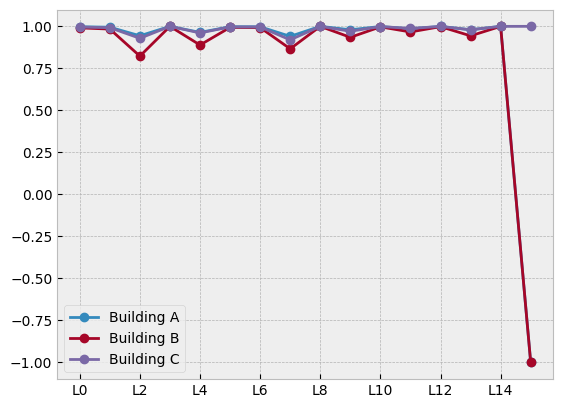

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('bmh')
cosines_dfs['gru'].T.plot(kind = 'line', marker = 'o')
#sns.lineplot(data=cosine_df, x=)

# Comparación métricas HFL

Comparamos las métricas de las federaciones periféricas con las del servidor agregado global.
Para ello organizamos las métricas en un gran DataFrame donde tenemos los campo de :
- **Federación** : Si son la raíz o alguna de las subfederaciones
- **Modelo** : El módelo que están entrenando
- **Ronda** : La ronda en la que se tomaron estas métricas.
- Un campo por cada **métrica**

De esta manera se realizaran los siguiente gráficos:
- Comparación root con HFL: Un gráfico para cada modelo y métrica con el número de ronda como ponente dependiente (X) y la métrica variable independiente (y). Se agrupan por federaciones para que cada una tenga su propia línea en el grafico.
- Comparación modelos: Un gráfico por métrica donde _x_ sea el número de ronda e _y_ sea la métrica. Se agrupan los modelos para que cada uno tenga su propia línea utilizandos los datos datos por la federación root.

In [9]:
# Definición de forma del dtaframe
col_model = "Modelo"
col_federation = "Federación"
col_round = "Ronda"
metrics_name = ["MAE", "MEDAE", "MSE", "RMSE", "MSLE", "MAPE", "R²", "Explained Variance", "Max Error", "Cosine Similarity"]

df_schema = {
    col_model : "string",
    col_federation : "string",
    col_round : "int64",
    **{col: "float64" for col in metrics_name}
}

df_HFL = pd.DataFrame(columns=df_schema.keys())
df_HFL = df_HFL.astype(df_schema)

In [10]:
# Aquí el primer hueco es para el modelo, el segundo para el número de ronda y el tercero para el paradigma
METRICS_DIRECTORY = "../../metrics/{}/{}/{}/{}"
edge_metrics_files = ["edgefederation_buildingA-data.json", "edgefederation_buildingB-data.json", "edgefederation_buildingC-data.json"]
for model in models:
    for i in range(1, rounds+1):
        # Primero la federación raiz de forma separada 
        filepath = METRICS_DIRECTORY.format(model, i, "HFL", "root_federation.json")
        with open(filepath, "r") as f:
            data = json.loads(f.read())
        row = [model, "root", i]
        for metric in metrics_used:
            row.append(data[metric])
        df_HFL.loc[len(df_HFL)] = row

        for file, name in zip(edge_metrics_files, names):
            filepath = METRICS_DIRECTORY.format(model, i, "HFL", file)
            with open(filepath, "r") as f:
                data = json.loads(f.read())
            row = [model, name, i]
            for metric in metrics_used:
                row.append(data["aggregated_metrics"][metric])
            df_HFL.loc[len(df_HFL)] = row

df_HFL.head()

,Modelo,Federación,Ronda,MAE,MEDAE,MSE,RMSE,MSLE,MAPE,R²,Explained Variance,Max Error,Cosine Similarity
0,gruSimple,root,1,0.070467,0.053720,0.010861,0.104216,0.006665,147.044253,0.427306,0.457911,0.777681,0.857268
1,gruSimple,Building A,1,0.044799,0.032434,0.003939,0.062759,0.002537,95.807091,0.707005,0.707019,0.383201,0.960320
2,gruSimple,Building B,1,0.058484,0.043743,0.006973,0.083504,0.004153,84.628578,0.637156,0.646868,0.565774,0.929547
3,gruSimple,Building C,1,0.077822,0.044582,0.018014,0.134217,0.009163,123.961899,0.519354,0.519485,0.738163,0.843161
4,gruSimple,root,2,0.053662,0.036908,0.007842,0.088554,0.004473,89.699101,0.586508,0.587373,0.832232,0.897334


## Comparación root con HFL

In [11]:
plot_dir = Path("plots")

In [ ]:
df_HFL = df_HFL.sort_values(by=["Federación", "Ronda"])

sns.set_theme(style="whitegrid")
root_hfl_dir = plot_dir / "RootHFL"
for model in models:
    df_filtered = df_HFL[df_HFL["Modelo"] == model]

    output_dir = root_hfl_dir / model
    output_dir.mkdir(parents=True, exist_ok=True)

    for y in metrics_name:
        plt.figure(figsize=(8,5))

        sns.lineplot(
            data = df_filtered,
            x = "Ronda",
            y= y,
            hue="Federación",
            markers="o",
            palette="tab10",
        )

        plt.title(f"Modelo: {model} | Metrica: {y}")
        plt.xlabel("Número de Rondas")
        plt.ylabel(y)

        file_path = output_dir / f"plot_{y}.png"

        plt.tight_layout()
        plt.savefig(file_path, dpi=300)
        plt.close()

## Comparación de modelos

In [12]:
output_dir = plot_dir / "ModelsHFL"   
output_dir.mkdir(parents=True, exist_ok=True)


df_filtered = df_HFL[df_HFL["Federación"] == "root"]

for y in metrics_name:
    plt.figure(figsize=(8,5))

    sns.lineplot(
        data = df_filtered,
        x = "Ronda",
        y= y,
        hue="Modelo",
        markers="o",
        palette="tab10",
    )

    plt.title(f"Comparación modelos en HFL | Metrica: {y}")
    plt.xlabel("Número de Rondas")
    plt.ylabel(y)

    file_path = output_dir / f"plot_{y}.png"

    plt.tight_layout()
    plt.savefig(file_path, dpi=300)
    plt.close()

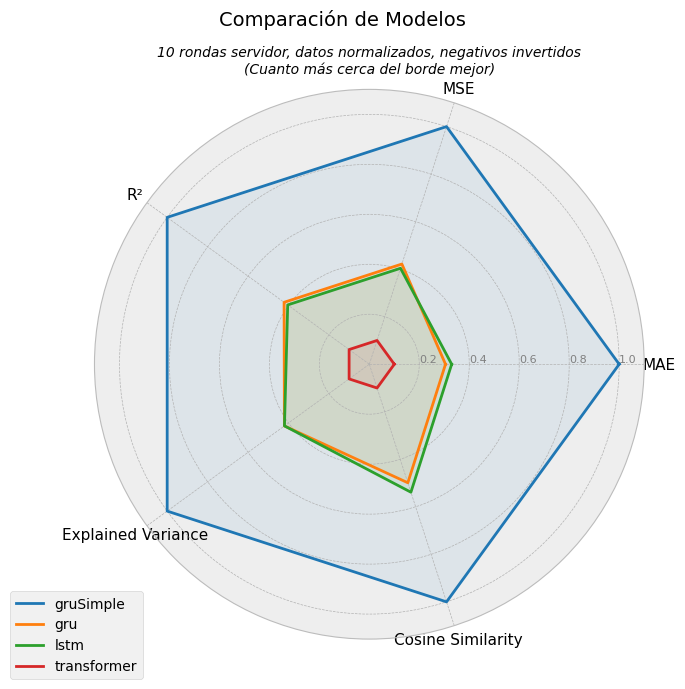

In [34]:
radar_metrics = ["MAE", "MSE", "R²", "Explained Variance", "Cosine Similarity"]

df_filtered = df_HFL[df_HFL["Ronda"] == 10 ]
df_filtered = df_filtered[df_filtered["Federación"] == "root"]
df_filtered = df_filtered[df_filtered["Modelo"] != "convlstm"]
df_norm = df_filtered[["Modelo"]].copy()

# 2. Normalize metrics between 0.1 and 1.0 so "outer" is always "better"
for metric in radar_metrics:
    min_val = df_filtered[metric].min()
    max_val = df_filtered[metric].max()
    
    if metric in ["R²", "Cosine Similarity", "Explained Variance"]:
        # Higher is better: standard min-max scaling
        df_norm[metric] = 0.1 + 0.9 * (df_filtered[metric] - min_val) / (max_val - min_val)
    else:
        # Lower is better: invert the min-max scaling
        df_norm[metric] = 0.1 + 0.9 * (max_val - df_filtered[metric]) / (max_val - min_val)

# 3. Setup polar coordinates background
num_vars = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the radar loop geometrically

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# Draw one axis per variable and add labels
plt.xticks(angles[:-1], radar_metrics, color='black', size=11)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.1)



# 4. Plot each model's line and fill the polygon
#colors = ['#1f77b4', '#4800ff', '#2ca02c', '#d62728', '#ffef00']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
#colors = ['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600']
spider_models:pd.Series = df_filtered["Modelo"]
spider_models = spider_models[spider_models != "convlstm"]
for i, model in enumerate(spider_models):
    # Extract values and close the geometric loop
    values = df_norm.loc[df_norm['Modelo'] == model, radar_metrics].values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.08)

# Formatting adjustments
plt.suptitle("Comparación de Modelos", size=14)
plt.title("10 rondas servidor, datos normalizados, negativos invertidos\n(Cuanto más cerca del borde mejor)", size=10, style='italic')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig("radar_chart.png")

In [ ]:

spider_models

36       gruSimple
76             gru
116           lstm
196    transformer
Name: Modelo, dtype: object

# Comparaciones FL

In [29]:
df_FL = pd.DataFrame(columns=df_schema.keys())
df_FL = df_FL.astype(df_schema)

In [30]:
for model in models:
    for i in range(1, rounds+1):
        # Primero la federación raiz de forma separada 
        filepath = METRICS_DIRECTORY.format(model, i, "FL", "edgefederation_combined-data.json")
        with open(filepath, "r") as f:
            data = json.loads(f.read())
        row = [model, "root", i]
        for metric in metrics_used:
            row.append(data["aggregated_metrics"][metric])
        df_FL.loc[len(df_FL)] = row

df_FL.head()

,Modelo,Federación,Ronda,MAE,MEDAE,MSE,RMSE,MSLE,MAPE,R²,Explained Variance,Max Error,Cosine Similarity
0,gruSimple,root,1,0.041180,0.025496,0.005717,0.075610,0.003189,59.336388,0.698555,0.698867,0.817710,0.926202
1,gruSimple,root,2,0.039949,0.023357,0.005662,0.075244,0.003115,51.438377,0.701468,0.702006,0.848317,0.927055
2,gruSimple,root,3,0.039017,0.023500,0.005412,0.073566,0.002972,50.659718,0.714635,0.715447,0.847650,0.930459
3,gruSimple,root,4,0.040341,0.024828,0.005488,0.074079,0.003029,51.295998,0.710636,0.714462,0.828563,0.930384
4,gruSimple,root,5,0.037077,0.020607,0.005282,0.072679,0.002887,45.692425,0.721471,0.722890,0.847902,0.932102


In [33]:
# 1. Combine them using keys to track the origin
combined_df = pd.concat([df_HFL, df_FL], keys=["HFL", "FL"])

# 2. Convert the source index into a regular column
combined_df = combined_df.reset_index(level=0).rename(
    columns={"level_0": "source"}
)

# 3. Optional: Reset the row index to clean things up
combined_df = combined_df.reset_index(drop=True)

In [43]:
output_dir = plot_dir / "HFLvFL"   
output_dir.mkdir(parents=True, exist_ok=True)
df_filtered = combined_df[combined_df["Federación"] == "root"]

style_mapping = {
    "FL": (1, 0),       # Solid line (1 point on, 0 points off)
    "HFL": (4, 4),       # Dashed line (4 points on, 4 points off)
    # If your column 'Paradigma' has different category values, 
    # replace "A" and "B" with those exact names!
}
for y in metrics_name:
    plt.figure(figsize=(8,5))

    sns.lineplot(
        data = df_filtered,
        x = "Ronda",
        y= y,
        hue="Modelo",
        style="Paradigma",
        dashes=style_mapping,
        markers=True,
        palette="tab10",
    )

    plt.title(f"Comparación FL vs HFL | Metrica: {y}")
    plt.xlabel("Número de Rondas")
    plt.ylabel(y)

    file_path = output_dir / f"plot_{y}.png"

    plt.tight_layout()
    plt.savefig(file_path, dpi=300)
    plt.close()